In [2]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import sys
import re

# import some tools from the wider directory
sys.path.insert(0, os.path.abspath('..'))   # adds fastersimulation/ to the path
import utilities

In [5]:
# sweep through folders and collate data
path = '../results/time_step_sweep/'
# ── Discover all app_* folders ──────────
app_dirs = [
    d for d in os.listdir(path)
    if os.path.isdir(os.path.join(path, d)) and d.startswith('app_')
]
def _parse_folder(folder_name):
    # Extracts the exact floats for app_area and focal out of the text string!
    m = re.search(r'ffdt_([^_]+)_mrdt_([^_/]+)', folder_name)
    if m:
        return float(m.group(1)), float(m.group(2))
    return -1.0, -1.0
# Sort hierarchically by Area, then Focal Length
app_dirs.sort(key=lambda d: _parse_folder(d))
out_path = os.path.join(path, 'combined_sweep.h5')
missing  = []
print(f"Collating {len(app_dirs)} folders into {out_path}...")
with h5py.File(out_path, 'w') as out_f:
    for folder in app_dirs:
        area_val, focal_val = _parse_folder(folder)
        
        h5_path = os.path.join(path, folder, 'mirror_states.h5')
        if not os.path.isfile(h5_path):
            print(f"  [SKIP] area={area_val}, focal={focal_val} — mirror_states.h5 not found")
            missing.append(folder)
            continue
            
        # Create a perfectly unique group name for this configuration!
        group_name = f'app_{area_val}_focal_{focal_val}'
        
        with h5py.File(h5_path, 'r') as src_f:
            # h5py.copy recursively copies all datasets, groups and attributes
            src_f.copy('/', out_f, name=group_name)
            
        print(f"  [OK]   {folder}  →  {group_name}/")
print(f"\nSaved combined file → {out_path}")
if missing:
    print(f"WARNING: {len(missing)} folders had no mirror_states.h5 file!")

Collating 0 folders into ../results/time_step_sweep/combined_sweep.h5...

Saved combined file → ../results/time_step_sweep/combined_sweep.h5


In [ ]:
def _h5_tree(item, indent=0, max_seg=2):
    """Recursively print HDF5 tree, collapsing repeated segment_ groups."""
    prefix = "  " * indent
    
    if isinstance(item, h5py.File):
        print(f"{prefix}/ (attrs: {dict(item.attrs)})")
        
        # Helper to extract (area, focal) from "app_113.10_focal_5000.0" for sorting
        def _parse_grp(x):
            if not x.startswith('app_'): return (-1.0, -1.0)
            parts = x.split('_')
            try:
                # Expecting: app, AREA, focal, FOCAL
                return (float(parts[1]), float(parts[3]))
            except (IndexError, ValueError):
                return (-1.0, -1.0)
                
        children = sorted(item.keys(), key=_parse_grp)
        for k in children:
            _h5_tree(item[k], indent+1, max_seg)
            
    elif isinstance(item, h5py.Group):
        name = item.name.split('/')[-1]
        children = list(item.keys())
        seg_keys = sorted([k for k in children if k.startswith('segment_')],
                          key=lambda x: int(x.split('_')[1]))
        other_keys = [k for k in children if not k.startswith('segment_')]
        print(f"{prefix}┣ {name}/")
        
        for k in sorted(other_keys):
            _h5_tree(item[k], indent+1, max_seg)
            
        # Show first N segments then summarise the rest
        for k in seg_keys[:max_seg]:
            _h5_tree(item[k], indent+1, max_seg)
        if len(seg_keys) > max_seg:
            print(f"{'  '*(indent+1)}┆ ... ({len(seg_keys) - max_seg} more segment_ groups)")
            
    elif isinstance(item, h5py.Dataset):
        name = item.name.split('/')[-1]
        dtype = item.dtype
        shape = item.shape
        print(f"{prefix}┃  {name:30s}  {str(shape):20s}  {dtype}")

# ── Execute the Tree Printer ──
#out_path = '../results/ring_vs_focal_sweep/combined_sweep.h5'

with h5py.File(out_path, 'r') as f:
    _h5_tree(f, max_seg=1)   # show only 1 segment per run to keep it readable


/ (attrs: {})
  ┣ app_177.42_focal_2500.0/
    ┣ config/
      ┃  star_vector                     (3,)                  float64
    ┃  mirror_time                     (2400,)               float64
    ┃  phase                           (28501,)              object
    ┃  r_app_eci                       (28501, 3)            float64
    ┃  r_det_eci                       (28501, 3)            float64
    ┃  rel_pos_B                       (2400, 3)             float64
    ┃  rel_sigma_B                     (28501, 3)            float64
    ┃  sigma_app_star                  (28501, 3)            float64
    ┃  sigma_det_star                  (28501, 3)            float64
    ┃  time                            (28501,)              float64
    ┣ segment_0/
      ┃  desired_mirror_actuation        (2400, 6)             float64
      ┃  mirror_actuation                (2400, 6)             float64
      ┃  point_on_det_plane              (2400, 2)             float64
      ┃  position     

In [4]:
with h5py.File(out_path, 'r') as src_f:
    
    # Helper to extract (area, focal) from group names for perfect sorting
    def _parse_grp(x):
        if not x.startswith('app_'): return (-1.0, -1.0)
        parts = x.split('_')
        try:
            # Expected format: app, AREA, focal, FOCAL
            return (float(parts[1]), float(parts[3]))
        except (IndexError, ValueError):
            return (-1.0, -1.0)
            
    # Get all the exact group keys directly from the file, perfectly sorted!
    # These strings will be exactly like: "app_113.10_focal_5000.0"
    group_keys = sorted([k for k in src_f.keys() if k.startswith('app_')], key=_parse_grp)
    num_runs = len(group_keys)
    print(f'Total number of simulation runs = {num_runs}')

    # Read segment count dynamically from the very first group
    first_group = group_keys[0]
    segs = sorted([int(k.split('_')[1]) for k in src_f[first_group].keys() if k.startswith('segment_')])
    num_of_segs = len(segs)
    print(f'Number of segments = {num_of_segs}')

    # Initialize lists to hold the varying-length arrays
    phase = []
    full_times = []
    eng_times = []
    
    # Parameters for the new grid (Area and Focal Length)
    area_vals = []
    focal_vals = []
    
    # Translation (Position) variables
    r_app_eci = []
    r_det_eci = []
    rel_pos_B = []
    
    # Rotation (Attitude) variables
    sigma_app_star = []
    sigma_det_star = []
    rel_sigma_B = []
    
    # Segment-specific variables
    mirror_actuation = []
    desired_mirror_actuation = []
    point_on_det_plane = []

    # Loop through the exact group strings
    for group in group_keys:
        
        # Keep track of the physical variables for this run
        area, focal = _parse_grp(group)
        area_vals.append(area)
        focal_vals.append(focal)
        
        # Depending on how the string array was saved, it might be stored as byte strings
        # .astype(str) ensures it converts b'fine' back to a normal python string 'fine'
        phase.append(src_f[group]['phase'][:].astype(str))
        
        # Extract the time arrays for this specific run
        full_times.append(src_f[group]['time'][:])
        eng_times.append(src_f[group]['mirror_time'][:])
        
        # Append Translation (Position) arrays
        r_app_eci.append(src_f[group]['r_app_eci'][:])
        r_det_eci.append(src_f[group]['r_det_eci'][:])
        rel_pos_B.append(src_f[group]['rel_pos_B'][:])
        
        # Append Rotation (Attitude MRP) arrays
        sigma_app_star.append(src_f[group]['sigma_app_star'][:])
        sigma_det_star.append(src_f[group]['sigma_det_star'][:])
        rel_sigma_B.append(src_f[group]['rel_sigma_B'][:])
        
        # Gather all segments into temporary lists for this specific run
        ma_segments = []
        dma_segments = []
        podp_segments = []
        
        for s in segs:
            ma_segments.append(src_f[group][f'segment_{s}']['mirror_actuation'][:])
            dma_segments.append(src_f[group][f'segment_{s}']['desired_mirror_actuation'][:])
            podp_segments.append(src_f[group][f'segment_{s}']['point_on_det_plane'][:])
            
        # Append the nested list of segments to the master lists
        mirror_actuation.append(ma_segments)
        desired_mirror_actuation.append(dma_segments)
        point_on_det_plane.append(podp_segments)

print("Data successfully loaded into lists!")


Total number of simulation runs = 12
Number of segments = 7
Data successfully loaded into lists!


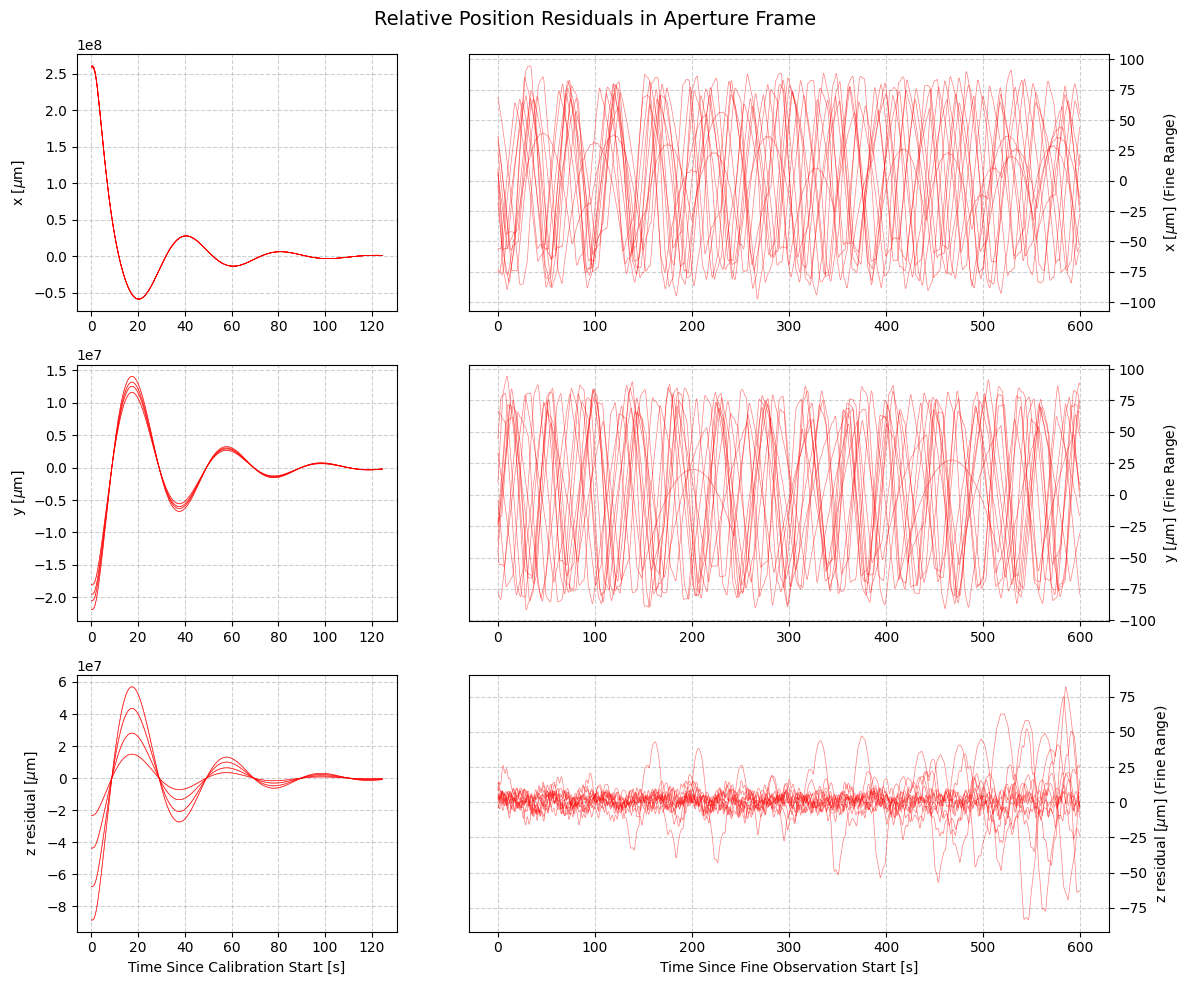

In [14]:
coord_letter = ['x', 'y', 'z']
# Dynamically scale opacity based on the massive 3D grid size
#alpha_lines = 1 - 0.5**(1/num_runs)
alpha_lines = 0.5


# 1. Set up the figure and GridSpec 
rel_pos_fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2], figure=rel_pos_fig)
rel_pos_fig.suptitle('Relative Position Residuals in Aperture Frame', fontsize=14)

rel_pos_ax = []

for row in range(3):
    ax_cal = rel_pos_fig.add_subplot(gs[row, 0])
    
    # We turn off sharey=ax_cal so the Fine plots can uniquely zoom in on their tighter tolerance!
    ax_fine = rel_pos_fig.add_subplot(gs[row, 1])
    
    # Move the fine y-ticks to the right side so they don't overlap the LHS graphs!
    ax_fine.yaxis.tick_right()
    ax_fine.yaxis.set_label_position("right")
    
    rel_pos_ax.append((ax_cal, ax_fine))

rel_pos_ax[2][0].set_xlabel('Time Since Calibration Start [s]')
rel_pos_ax[2][1].set_xlabel('Time Since Fine Observation Start [s]')

for coord in range(len(coord_letter)):
    label = f'{coord_letter[coord]}'
    if coord == 2:
        label = 'z residual' # Clarify it's a residual
        
    rel_pos_ax[coord][0].set_ylabel(f'{label} [$\mu$m]')
    rel_pos_ax[coord][1].set_ylabel(f'{label} [$\mu$m] (Fine Range)')
    
    # Add grid lines to all subplots
    rel_pos_ax[coord][0].grid(True, linestyle='--', alpha=0.6)
    rel_pos_ax[coord][1].grid(True, linestyle='--', alpha=0.6)

# 2. Plot all simulation sweeps
for i in range(num_runs):
    t_eng = eng_times[i]
    rel = rel_pos_B[i]
    current_focal = focal_vals[i] # Get the target focal length for this specific run
    
    # EXPLICITLY find start/end times of each phase for THIS run
    cal_idx  = np.where(phase[i] == 'Calibration')[0]
    fine_idx = np.where(phase[i] == 'Fine Observation')[0]
    
    # Mask exactly the 'Calibration' windows
    if len(cal_idx) > 0:
        cal_start, cal_end = full_times[i][cal_idx[0]], full_times[i][cal_idx[-1]]
        cal_mask = (t_eng >= cal_start) & (t_eng <= cal_end)
    else:
        cal_mask = np.zeros_like(t_eng, dtype=bool)
        
    # Mask exactly the 'Fine Observation' windows
    if len(fine_idx) > 0:
        fine_start, fine_end = full_times[i][fine_idx[0]], full_times[i][fine_idx[-1]]
        fine_mask = (t_eng >= fine_start) & (t_eng <= fine_end)
    else:
        fine_mask = np.zeros_like(t_eng, dtype=bool)

    # Slice the arrays using the masks
    cal_t       = t_eng[cal_mask]
    cal_rel     = rel[cal_mask]
    
    fine_t      = t_eng[fine_mask]
    fine_rel    = rel[fine_mask]

    cal_t       = cal_t[:250]
    cal_rel     = cal_rel[:250]

    # Shift times so both phases start exactly at t=0
    if len(cal_t) > 0:
        cal_t = cal_t - cal_t[0]
    if len(fine_t) > 0:
        fine_t = fine_t - fine_t[0]

    for coord in range(len(coord_letter)):
        # Calculate values to plot
        cal_vals = cal_rel[:, coord]
        fine_vals = fine_rel[:, coord]
        
        # Subtract focal length if plotting the Z-axis to show residuals
        if coord == 2:
            cal_vals = cal_vals - current_focal
            fine_vals = fine_vals - current_focal

        # Plot Calibrating Phase on LHS (Multiply by 1e6 for micrometers)
        if len(cal_t) > 0:
            rel_pos_ax[coord][0].plot(cal_t, cal_vals * 1e6, linewidth=0.5, color='red', alpha=alpha_lines)
            
        # Plot Fine Observation Phase on RHS (Multiply by 1e6 for micrometers)
        if len(fine_t) > 0:
            rel_pos_ax[coord][1].plot(fine_t, fine_vals * 1e6, linewidth=0.5, color='red', alpha=alpha_lines)

plt.tight_layout()
plt.subplots_adjust(wspace=0.15) 
plt.show()


Generating heatmap grid for 3 Areas x 4 Focal Lengths...


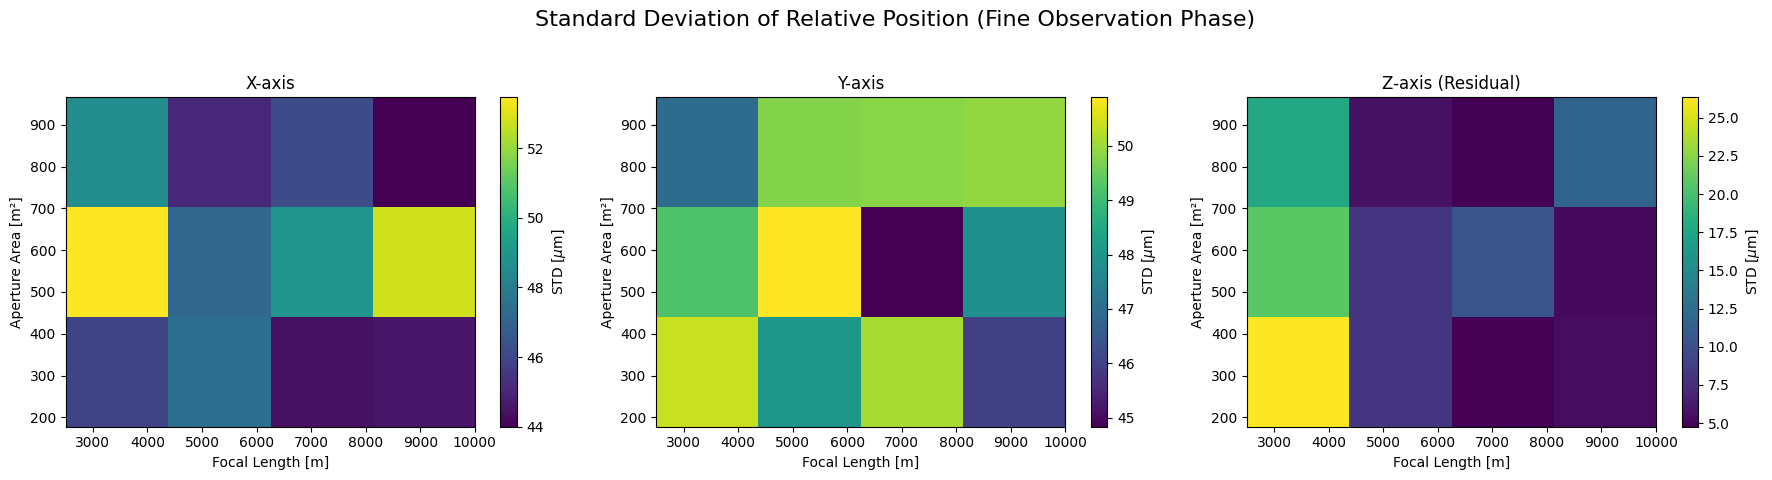

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Identify unique parameter values for the grid axes
unique_areas = sorted(list(set(area_vals)))
unique_focals = sorted(list(set(focal_vals)))

# 2. Initialize grids for each coordinate (Rows = Area, Cols = Focal Length)
std_grid_x = np.zeros((len(unique_areas), len(unique_focals)))
std_grid_y = np.zeros((len(unique_areas), len(unique_focals)))
std_grid_z = np.zeros((len(unique_areas), len(unique_focals)))

print(f"Generating heatmap grid for {len(unique_areas)} Areas x {len(unique_focals)} Focal Lengths...")

# 3. Populate the grids
for i in range(num_runs):
    t_eng = eng_times[i]
    rel = rel_pos_B[i]
    current_area = area_vals[i]
    current_focal = focal_vals[i]
    
    # Find Fine Observation indices
    fine_idx = np.where(phase[i] == 'Fine Observation')[0]
    if len(fine_idx) > 0:
        fine_start, fine_end = full_times[i][fine_idx[0]], full_times[i][fine_idx[-1]]
        fine_mask = (t_eng >= fine_start) & (t_eng <= fine_end)
        fine_rel = rel[fine_mask]
        
        if len(fine_rel) > 0:
            # Calculate STD for each axis (subtract focal from z for residual STD)
            std_x = np.std(fine_rel[:, 0])
            std_y = np.std(fine_rel[:, 1])
            std_z = np.std(fine_rel[:, 2] - current_focal)
            
            # Find coordinates in our heatmap matrix
            r = unique_areas.index(current_area)
            c = unique_focals.index(current_focal)
            
            std_grid_x[r, c] = std_x
            std_grid_y[r, c] = std_y
            std_grid_z[r, c] = std_z

# 4. Plotting the Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Standard Deviation of Relative Position (Fine Observation Phase)', fontsize=16)

coords = ['X-axis', 'Y-axis', 'Z-axis (Residual)']
grids = [std_grid_x, std_grid_y, std_grid_z]

for ax, grid, title in zip(axes, grids, coords):
    # Multiply by 1e6 to show micrometers
    im = ax.imshow(grid * 1e6, origin='lower', aspect='auto',
                   extent=[min(unique_focals), max(unique_focals), min(unique_areas), max(unique_areas)],
                   cmap='viridis')
    
    ax.set_title(title)
    ax.set_xlabel('Focal Length [m]')
    ax.set_ylabel('Aperture Area [m²]')
    
    # Add colorbar for each subplot
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('STD [$\mu$m]')

plt.tight_layout()
plt.subplots_adjust(wspace=0.15) 
plt.savefig(f'{path}/heatplot.png')
